In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import torch.optim as optim
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import torch.nn.functional as F
import math
from nltk.corpus import stopwords

In [2]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
device

'cuda'

In [3]:
image_files = os.listdir("data/images")
print(len(image_files))

8092


In [4]:
print(os.listdir("data"))

['.ipynb_checkpoints', 'images', 'text']


In [5]:
print(image_files[:5])

['.ipynb_checkpoints', '1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg']


In [6]:
text_path = "data/text/captions.txt"

with open(text_path) as f:
    for _ in range(20):
        print(f.readline().strip())

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .
1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .
1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
1002674143_1b742ab4b8

In [7]:
data_text = pd.read_csv(text_path)

In [8]:
data_text.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [9]:
data_text.shape

(40455, 2)

In [10]:
data_text["image"].nunique()

8091

In [11]:
8091 * 5

40455

In [12]:
print(data_text.groupby("image").size().value_counts())

5    8091
Name: count, dtype: int64


In [13]:
unique_images = data_text["image"].unique()

In [14]:
train_images, temp_images_holder = train_test_split(
    unique_images, test_size = 0.3, random_state = 42
)

val_images, test_images = train_test_split(
    temp_images_holder, test_size = 0.5, random_state = 42
)

In [15]:
train_df = data_text[data_text["image"].isin(train_images)]
test_df = data_text[data_text["image"].isin(test_images)]
validation_df = data_text[data_text["image"].isin(val_images)]

In [16]:
train_df.head(10)

,image,caption
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .
10,1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front o...
11,1002674143_1b742ab4b8.jpg,A little girl is sitting in front of a large p...
12,1002674143_1b742ab4b8.jpg,A small girl in the grass plays with fingerpai...
13,1002674143_1b742ab4b8.jpg,There is a girl with pigtails sitting in front...
14,1002674143_1b742ab4b8.jpg,Young girl with pigtails painting outside in t...


In [17]:
class Vocabulary:
    def __init__(self, min_freq = 5):
        
        # threshold
        self.min_freq = min_freq

        # special characters / tokens
        self.pad_token = "<pad>"
        self.start_token = "<start>"
        self.end_token = "<end>"
        self.unk_token = "<unk>"

        # word -> indx mapping
        self.word2idx = {
            self.pad_token : 0,
            self.start_token : 1,
            self.end_token : 2,
            self.unk_token : 3
        }

        # indx -> word mapping
        self.idx2word = {
            0 : self.pad_token,
            1 : self.start_token,
            2 : self.end_token,
            3 : self.unk_token
        }

        # Counter = counts words frequency
        self.word_freq = {}

    def build_vocabulary(self, captions: list[str]) -> None:
        """
        Building vocabulary from training captions
        """
        for sentence in captions:
            for word in sentence.lower().split():
                if word in self.word_freq:
                    self.word_freq[word] += 1
                else:
                    self.word_freq[word] = 1

        # Words which pass the threshold
        for word in self.word_freq:
            if self.word_freq[word] >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def numericalize(self, caption: str) -> list[int]:
        """
        Convert a string into a list of token
        """
        tokens = [self.word2idx[self.start_token]]
        for word in caption.lower().split():
            if word in self.word2idx:
                tokens.append(self.word2idx[word])
            else:
                tokens.append(self.word2idx[self.unk_token])
        tokens.append(self.word2idx[self.end_token])
        return tokens

    def decode(self, tokens: list[int]) -> str:
        """ 
        Numerical to string value using the tokens
        """
        words = []
        for val in tokens:
            words.append(
                self.idx2word.get(val, self.unk_token)
            )
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

In [18]:
class ImageCaptionDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_dir,
        vocabulary,
        transform = None
    ):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.vocabulary = vocabulary
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_filename = row["image"]
        image_path = os.path.join(self.image_dir, image_filename)
        caption = row["caption"]

        # Opening image
        image = Image.open(image_path).convert("RGB")

        # Applying tranformation 
        if self.transform is not None:
            image = self.transform(image)
        caption_tensor = torch.tensor(
            self.vocabulary.numericalize(caption),
            dtype = torch.long
        )
        return (image, caption_tensor)

In [19]:
def collate_fn(batch):
    # Separate images and captions
    images = [item[0] for item in batch]
    captions = [item[1] for item in batch]

    # Stack images
    images = torch.stack(images)

    # Find max caption length
    max_length = max(len(caption) for caption in captions)

    padded_captions = []

    for caption in captions:
        padding_length = max_length - len(caption)
        if padding_length > 0:
            padding = torch.zeros(
                padding_length,
                dtype = torch.long
            )
            caption = torch.cat([caption, padding])
        padded_captions.append(caption)
    captions = torch.stack(padded_captions)
    return images, captions

In [20]:
class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()

        resnet = models.resnet50(
            weights = models.ResNet50_Weights.DEFAULT
        )

        # Removing last two layers as we only need to extract features
        modules = list(resnet.children())[: -2]
        self.resnet = nn.Sequential(*modules)

    def forward(self, images):
        features = self.resnet(images)
        features = features.flatten(start_dim = 2)
        features = features.permute(0, 2, 1)
        return features

In [21]:
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()

        self.encoder_att = nn.Linear(
            encoder_dim,
            attention_dim
        )

        self.decoder_att = nn.Linear(
            decoder_dim,
            attention_dim
        )

        self.full_att = nn.Linear(
            attention_dim,
            1
        )

        self.softmax = nn.Softmax(dim = 1)
        
    def forward(self, encoder_features, hidden_state):
        encoder_projection = self.encoder_att(encoder_features)
        decoder_projection = self.decoder_att(hidden_state)
        decoder_projection = decoder_projection.unsqueeze(1)

        # Raw scores for every area
        score = self.full_att(
            torch.tanh(
                encoder_projection + decoder_projection
            )
        ).squeeze(2)

        attention_weights = self.softmax(score)
        context_vector = (
            attention_weights.unsqueeze(2) * encoder_features
        ).sum(dim = 1)
        return context_vector, attention_weights

In [22]:
class DecoderWithAttention(nn.Module):
    def __init__(
        self,
        attention,
        embed_size,
        hidden_size,
        vocab_size,
        encoder_dim = 2048,
        dropout = 0.5
    ):
        super().__init__()
        self.attention = attention

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size
        )
        self.lstm = nn.LSTMCell(
            embed_size + encoder_dim,
            hidden_size
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )
    def forward(self, encoder_features, captions):
        batch_size = encoder_features.size(0)
        max_len = captions.size(1)

        # Convert token id to word embeddings
        embeddings = self.embedding(captions)

        # hidden state for short term
        h = torch.zeros(
            batch_size,
            self.lstm.hidden_size,
            device = encoder_features.device
        )

        # cell state for long term
        c = torch.zeros_like(h)
        predictions = []
        for i in range(max_len - 1):
            context, alpha = self.attention(
                encoder_features,
                h
            )

            # extract the embedding of the current input word
            word_embedding = embeddings[:, i, :]

            # concat word embedding and attention image features
            lstm_input = torch.cat(
                [word_embedding, context],
                dim = 1
            )

            # update hidden and cell state
            h, c = self.lstm(
                lstm_input,
                (h, c)
            )
            prediction = self.fc(
                self.dropout(h)
            )
            predictions.append(prediction)

        # convert list of predictions into a single tensor
        predictions = torch.stack(
            predictions,
            dim = 1
        )

        return predictions

    # --------------------------------------------------------------
    # --------------------------------------------------------------
    # --------------------------------------------------------------
    # --------------------------------------------------------------
    # --------------------------------------------------------------

        # helper function for a single decoding step
    def decode_step(
        self,
        encoder_features,
        current_word,
        hidden,
        cell
    ):
        embedding = self.embedding(current_word)
        
        context, alpha = self.attention( # alpha is attention weights
            encoder_features,
            hidden
        )

        # concat embedding and context
        lstm_input = torch.cat(
            [embedding.squeeze(1), context], dim = 1
        )

        # LSTM cell
        hidden, cell = self.lstm(
            lstm_input,
            (hidden, cell)
        )

        # Prediction
        predictions = self.fc(
            self.dropout(hidden)
        )
        return predictions, hidden, cell, alpha

    # Generate greedy caption
    def generate_caption(
        self,
        encoder_features,
        vocab,
        max_length=20
    ):

        batch_size = encoder_features.size(0)
    
        h = torch.zeros(
            batch_size,
            self.lstm.hidden_size,
            device=encoder_features.device
        )
    
        c = torch.zeros_like(h)
    
        current_word = torch.tensor(
            [vocab.word2idx["<start>"]],
            device=encoder_features.device
        )
    
        generated_caption = []
        attention_weights = []
    
        for _ in range(max_length):
            prediction, h, c, alpha = self.decode_step(
                encoder_features,
                current_word,
                h,
                c
            )
    
            predicted_word = prediction.argmax(dim=1)
            word = vocab.idx2word[
                predicted_word.item()
            ]
    
            if word == "<end>":
                break
    
            generated_caption.append(word)
            attention_weights.append(alpha)
            current_word = predicted_word
        return generated_caption, attention_weights

        
    
    # using beam search
    def generate_caption_beam_search(
        self,
        encoder_features,
        vocab,
        beam_size=3,
        max_length=20
    ):

        batch_size = encoder_features.size(0)
    
        # Initialize hidden and cell states
        h = torch.zeros(
            batch_size,
            self.lstm.hidden_size,
            device=encoder_features.device
        )
    
        c = torch.zeros_like(h)
    
        # Initial beam
        beams = [{
            "caption": [vocab.word2idx["<start>"]],
            "hidden": h,
            "cell": c,
            "score": 0.0,
            "attention": []
        }]
    
        # Generate words
        for _ in range(max_length):
    
            new_beams = []
    
            # Expand each current beam
            for beam in beams:
    
                caption = beam["caption"]
                hidden = beam["hidden"]
                cell = beam["cell"]
                score = beam["score"]
                attention = beam["attention"]
    
                # If this beam already ended keep it
                if caption[-1] == vocab.word2idx["<end>"]:
                    new_beams.append(beam)
                    continue
    
                # Current input word
                current_word = torch.tensor(
                    [[caption[-1]]], # as shape is 1,1
                    device=encoder_features.device
                )
    
                # Decode one step
                predictions, hidden, cell, alpha = self.decode_step(
                    encoder_features,
                    current_word,
                    hidden,
                    cell
                )
    
                # Convert logits to log probabilities
                log_probs = F.log_softmax(
                    predictions,
                    dim=1
                )
    
                # Keep top beam_size candidate words
                top_scores, top_words = log_probs.topk(
                    beam_size,
                    dim=1
                )
    
                # Create child beam for each candidate
                for i in range(beam_size):
    
                    next_word = top_words[0, i].item()
                    next_score = top_scores[0, i].item()
    
                    new_caption = caption + [next_word]
                    new_score = score + next_score
                    new_attention = attention + [alpha]
    
                    new_beams.append({
                        "caption": new_caption,
                        "hidden": hidden.clone(),
                        "cell": cell.clone(),
                        "score": new_score,
                        "attention": new_attention
                    })
    
            # Keep only the best beams
            new_beams = sorted(
                new_beams,
                key=lambda beam: beam["score"],
                reverse=True
            )
    
            beams = new_beams[:beam_size]
    
        # Best beam
        best_beam = beams[0]
    
        generated_caption = []
    
        # Convert token IDs to words
        for token in best_beam["caption"]:
    
            if token == vocab.word2idx["<start>"]:
                continue
    
            if token == vocab.word2idx["<end>"]:
                break
    
            generated_caption.append(
                vocab.idx2word[token]
            )
    
        return generated_caption, best_beam["attention"]

In [23]:
vocab = Vocabulary(min_freq = 5)
vocab.build_vocabulary(train_df["caption"].tolist())

In [24]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
image_dir = "data/images"

train_dataset = ImageCaptionDataset(
    dataframe = train_df,
    image_dir = image_dir,
    vocabulary = vocab,
    transform = transform
)
val_dataset = ImageCaptionDataset(
    dataframe = validation_df,
    image_dir = image_dir,
    vocabulary = vocab,
    transform = transform
)
test_dataset = ImageCaptionDataset(
    dataframe = test_df,
    image_dir = image_dir,
    vocabulary = vocab,
    transform = transform
)

In [26]:
train_loader = DataLoader(
    dataset = train_dataset,
    shuffle = True,
    batch_size = 16,
    collate_fn = collate_fn
)

val_loader = DataLoader(
    dataset = val_dataset,
    shuffle = False,
    batch_size = 16,
    collate_fn = collate_fn
)

test_loader = DataLoader(
    dataset = test_dataset,
    shuffle = False,
    batch_size = 16,
    collate_fn = collate_fn
)

In [27]:
print(type(train_loader.dataset))
print(train_loader.dataset)

<class '__main__.ImageCaptionDataset'>


In [28]:
# HyperParameters
embed_size = 256
hidden_size = 512
attention_dim = 256
encoder_dim = 2048
vocab_size = len(vocab)
num_epochs = 10

# Model Creation
encoder = EncoderCNN().to(device)
attention = BahdanauAttention(
    encoder_dim = encoder_dim,
    decoder_dim = hidden_size,
    attention_dim = attention_dim
)

decoder = DecoderWithAttention(
    attention = attention,
    embed_size = embed_size,
    hidden_size = hidden_size,
    vocab_size = vocab_size,
    encoder_dim = encoder_dim,
    dropout = 0.5
).to(device)

attention.to(device)

criterion = nn.CrossEntropyLoss(ignore_index = vocab.word2idx["<pad>"])
optimizer = optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters())
)

encoder.train()
decoder.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    for images, captions in train_loader:
        images = images.to(device)
        captions = captions.to(device)

        # Forward pass
        encoder_features = encoder(images)
        # print(encoder_features.shape)
        predictions = decoder(
            encoder_features,
            captions
        )
        targets = captions[:, 1:]

        # Compute loss
        loss = criterion(
            predictions.reshape(
                -1, 
                vocab_size
            ),
            targets.reshape(-1)
        )

        # Backpropogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)

    print(f"Epoch:{epoch + 1}/{num_epochs}, Loss: {avg_loss}")

Epoch:1/10, Loss: 3.3834490564583386
Epoch:2/10, Loss: 2.855683399997862
Epoch:3/10, Loss: 2.6533112982572136
Epoch:4/10, Loss: 2.504145652897614
Epoch:5/10, Loss: 2.3812084019520863
Epoch:6/10, Loss: 2.273609866058759
Epoch:7/10, Loss: 2.1713274614285614
Epoch:8/10, Loss: 2.076122146811189
Epoch:9/10, Loss: 1.9857077384399155
Epoch:10/10, Loss: 1.9031478538351543


In [43]:
torch.save({
    "epoch": epoch,
    "encoder": encoder.state_dict(),
    "decoder": decoder.state_dict(),
    "optimizer": optimizer.state_dict(),
    "loss": avg_loss
}, "checkpoint_1.pth")

In [28]:
torch.save(vocab, "vocab.pth")

In [29]:
def load_checkpoint(
    checkpoint_path,
    encoder,
    decoder,
    optimizer = None,
    device = "cuda"
):
    """ 
    Getting back all the modle parameters 
    """
    checkpoint = torch.load(
        checkpoint_path,
        map_location = device
    )
    encoder.load_state_dict(checkpoint["encoder"])
    decoder.load_state_dict(checkpoint["decoder"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer"])
    epoch = checkpoint.get("epoch", 0)
    loss = checkpoint.get("loss", None)

    print("Checkpoint Loaded successfully!")
    print(f"Loaded Checkpoint Path : {checkpoint_path}")
    print(f"Epoch : {epoch}")

    return epoch, loss

In [30]:
def create_models(
    vocab_size,
    device = "cuda",
    embed_size = 256,
    hidden_size = 512,
    attention_dim = 256,
    encoder_dim = 2048,
    num_epochs = 10
):
    encoder = EncoderCNN().to(device)
    attention = BahdanauAttention(
        encoder_dim = encoder_dim,
        decoder_dim = hidden_size,
        attention_dim = attention_dim
    ).to(device)

    decoder = DecoderWithAttention(
        attention = attention,
        embed_size = embed_size,
        hidden_size = hidden_size,
        vocab_size = vocab_size,
        encoder_dim = encoder_dim,
        dropout = 0.5
    ).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index = vocab.word2idx["<pad>"])
    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters())
    )

    return encoder, attention, decoder, criterion, optimizer

In [31]:
def get_models(
    vocab,
    device = "cuda",
    checkpoint_path = None
):
    encoder, attention, decoder, criterion, optimizer = create_models(
        vocab_size = len(vocab),
        device = device
    )
    start_epoch = 0
    loss = None
    if checkpoint_path is not None:
        start_epoch, loss = load_checkpoint(
            checkpoint_path = checkpoint_path,
            encoder = encoder,
            decoder  = decoder,
            optimizer = optimizer,
            device = device
        )
    return encoder, attention, decoder, criterion, optimizer, start_epoch, loss

In [32]:
encoder, attention, decoder, criterion, optimizer, start_epoch, loss = get_models(
        vocab=vocab,
        device=device,
        checkpoint_path = "best_model.pth"
    )

encoder.train()
decoder.train()

Checkpoint Loaded successfully!
Loaded Checkpoint Path : best_model.pth
Epoch : 10


DecoderWithAttention(
  (attention): BahdanauAttention(
    (encoder_att): Linear(in_features=2048, out_features=256, bias=True)
    (decoder_att): Linear(in_features=512, out_features=256, bias=True)
    (full_att): Linear(in_features=256, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (embedding): Embedding(2494, 256)
  (lstm): LSTMCell(2304, 512)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2494, bias=True)
)

In [33]:
# Trying it on the validation set

encoder.eval()
decoder.eval()
val_loss = 0
with torch.no_grad():
    for images, captions in val_loader:
        images = images.to(device)
        captions = captions.to(device)

        encoder_features = encoder(images)
        predictions = decoder(
            encoder_features,
            captions
        )
        targets = captions[:, 1:]
        loss = criterion(
            predictions.reshape(-1, len(vocab)),
            targets.reshape(-1)
        )
        val_loss += loss.item()
val_loss = val_loss / len(val_loader)
print(f"Validation Loss : {val_loss}")   

Validation Loss : 2.7176295854543384


In [33]:
encoder.train()
decoder.train()
best_val_loss = loss # loss of the last model trained
for epoch in range(start_epoch + 1, 15):

    # Training
    train_loss = 0
    for images, captions in train_loader:
        images = images.to(device)
        captions = captions.to(device)
        encoder_features = encoder(images)
        predictions = decoder(encoder_features, captions)
        targets = captions[:, 1:]
        loss = criterion(
            predictions.reshape(-1, len(vocab)),
            targets.reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss  / len(train_loader)

    # Validation
    encoder.eval()
    decoder.eval()
    
    val_loss = 0
    with torch.no_grad():
        for images, captions in val_loader:
            images = images.to(device)
            captions = captions.to(device)
            encoder_features = encoder(images)
            predictions = decoder(
                encoder_features,
                captions
            )
            targets = captions[:, 1:]
            loss = criterion(
                predictions.reshape(-1, len(vocab)),
                targets.reshape(-1)
            )
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch : {epoch + 1}, Train Loss: {avg_train_loss}, Val Loss: {avg_val_loss}")

    torch.save({
        "epoch": epoch,
        "encoder": encoder.state_dict(),
        "decoder": decoder.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": avg_val_loss
    }, "pointcheck.pth")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch": epoch,
            "encoder": encoder.state_dict(),
            "decoder": decoder.state_dict(),
            "optimizer": optimizer.state_dict(),
            "loss": avg_val_loss
        }, "best_model.pth") 
        print("---- best model saved ----")

Epoch : 11, Train Loss: 1.8197491127218903, Val Loss: 2.745197650947069
Epoch : 12, Train Loss: 1.4075849751968168, Val Loss: 2.8430700098213397
Epoch : 13, Train Loss: 1.2112195636929766, Val Loss: 2.966683930472324
Epoch : 14, Train Loss: 1.047276774537092, Val Loss: 3.0906217443315604
Epoch : 15, Train Loss: 0.89660104422246, Val Loss: 3.2087090529893576


In [33]:
encoder, attention, decoder, criterion, optimizer, start_epoch, loss = get_models(
        vocab=vocab,
        device=device,
        checkpoint_path = "best_model.pth"
    )

Checkpoint Loaded successfully!
Loaded Checkpoint Path : best_model.pth
Epoch : 10


In [33]:
encoder.eval()
decoder.eval()

image, _ = test_dataset[122]

image = image.unsqueeze(0).to(device)

with torch.no_grad():

    features = encoder(image)

    caption, attention = decoder.generate_caption(
        features,
        vocab
    )

print("Generated Caption:")
print(" ".join(caption))

Generated Caption:
a boy in a blue shirt is running in a yard .


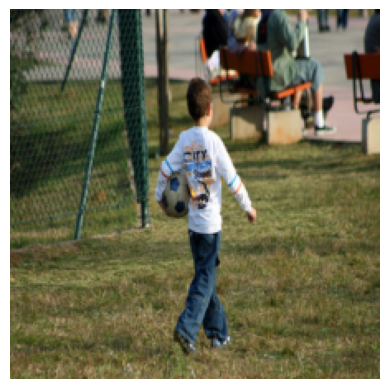

In [34]:
image, _ = test_dataset[122]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

display_image = image * std + mean
display_image = display_image.clamp(0,1)

plt.imshow(display_image.permute(1,2,0))
plt.axis("off")
plt.show()

In [34]:
def show_caption(indx):
    encoder.eval()
    decoder.eval()
    images, real_caption = test_dataset[indx]

    # Prepare Image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    display_image = images * std + mean
    display_image = display_image.clamp(0, 1)

    # Generate Caption
    images = images.unsqueeze(0).to(device)
    with torch.no_grad():
        encoder_features = encoder(images)

        captions, attention = decoder.generate_caption(
            encoder_features,
            vocab
        )
    # Find Real Caption
    real_caption = vocab.decode(real_caption.tolist())
    real_caption = real_caption.split()
    special_tokens = {"<start>", "<end>", "<pad>"}
    real_caption = [word for word in real_caption if word not in special_tokens]
    print("Generated Caption :", " ".join(captions))
    print("Real Caption      :", " ".join(real_caption))

    plt.figure(figsize=(8,8))
    plt.imshow(display_image.permute(1,2,0))
    plt.axis("off")
    plt.show()

Generated Caption : a man in a red shirt is walking on a street .
Real Caption      : a man sits and reads a newspaper by a sculpture outside of an office building .


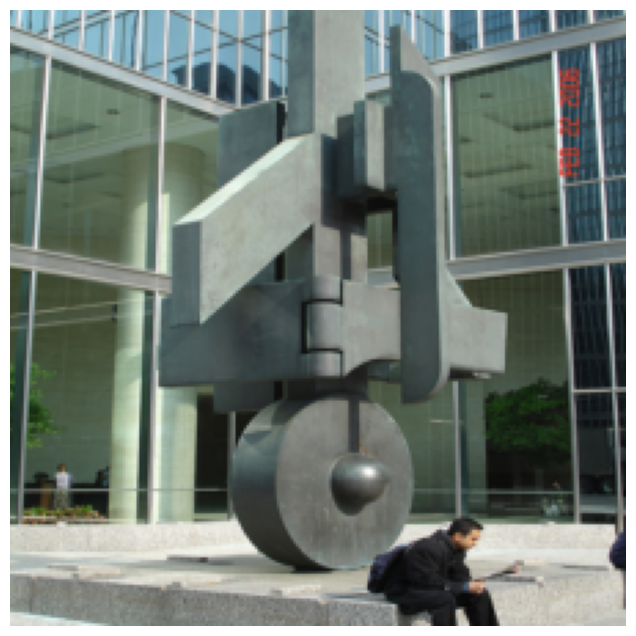

In [35]:
import random as rr
for i in range(1):
    show_caption(rr.randint(1,380))

In [36]:
image_to_captions = (
    test_df.groupby("image")["caption"].apply(list).to_dict()
)

In [37]:
unique_images = test_df['image'].unique()

In [37]:
references = []
hypotheses = []
encoder.eval()
decoder.eval()

smooth = SmoothingFunction().method1 # method 1 to add a small number in case p comes to be 0 matches

for image_name in unique_images:

    image_path = os.path.join(
        "data/images",
        image_name
    )

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        features = encoder(image)

        generated_caption, _ = decoder.generate_caption(
            features,
            vocab
        )

    hypotheses.append(generated_caption)

    reference_captions = []

    for caption in image_to_captions[image_name]:

        tokens = caption.lower().split()

        reference_captions.append(tokens)

    references.append(reference_captions)

In [39]:
bleu1 = corpus_bleu(
    references,
    hypotheses,
    weights=(1, 0, 0, 0),
    smoothing_function=smooth
)

bleu2 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smooth
)

bleu3 = corpus_bleu(
    references,
    hypotheses,
    weights=(1/3, 1/3, 1/3, 0),
    smoothing_function=smooth
)

bleu4 = corpus_bleu(
    references,
    hypotheses,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)

In [40]:
print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU-1: 0.5668
BLEU-2: 0.3470
BLEU-3: 0.2154
BLEU-4: 0.1361


In [38]:
def visualize_attention(indx):
    encoder.eval()
    decoder.eval()

    # Get image and its actual caption
    image, caption = test_dataset[indx]
    image = image.unsqueeze(0).to(device)

    # Generate Caption
    with torch.no_grad():
        features = encoder(image)
        predicted_caption, attention_weights = decoder.generate_caption(
            features,
            vocab
        )
    print(f"Predicted Captions: {" ".join(predicted_caption)}")

    # Undo Image Normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    display_image = image.squeeze(0).cpu()
    display_image = display_image * std + mean
    display_image = display_image.clamp(0, 1) # Limiting tensor between 0 - 1
    display_image = display_image.permute(1, 2, 0).numpy() 

    # Plotting Attention Maps
    cols = 5
    rows = math.ceil(len(predicted_caption) / cols)
    plt.figure(figsize = (10, 8))
    for i, (word, alpha) in enumerate(zip(predicted_caption, attention_weights)):
        alpha = alpha.squeeze(0)
        alpha = alpha.reshape(7, 7)
        alpha = alpha.unsqueeze(0).unsqueeze(0)
        
        alpha = F.interpolate(
            alpha,
            size = (224, 224),
            mode = "bilinear",
            align_corners = False
        )
        alpha = alpha.squeeze().cpu().numpy()
        plt.subplot(rows, cols, i + 1)
        
        plt.imshow(display_image)
        plt.imshow(alpha, cmap = "jet", alpha = 0.5)
    
        plt.title(word)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [39]:
def beam_visualize_attention(indx):
    encoder.eval()
    decoder.eval()

    # Get image and its actual caption
    image, caption = test_dataset[indx]
    image = image.unsqueeze(0).to(device)

    # Generate Caption
    with torch.no_grad():
        features = encoder(image)
        predicted_caption, attention_weights = decoder.generate_caption_beam_search(
            features,
            vocab,
            beam_size = 3
        )
    print(f"Predicted Captions: {" ".join(predicted_caption)}")

    # Undo Image Normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    display_image = image.squeeze(0).cpu()
    display_image = display_image * std + mean
    display_image = display_image.clamp(0, 1) # Limiting tensor between 0 - 1
    display_image = display_image.permute(1, 2, 0).numpy() 

    # Plotting Attention Maps
    cols = 5
    rows = math.ceil(len(predicted_caption) / cols)
    plt.figure(figsize = (10, 8))
    for i, (word, alpha) in enumerate(zip(predicted_caption, attention_weights)):
        alpha = alpha.squeeze(0)
        alpha = alpha.reshape(7, 7)
        alpha = alpha.unsqueeze(0).unsqueeze(0)
        
        alpha = F.interpolate(
            alpha,
            size = (224, 224),
            mode = "bilinear",
            align_corners = False
        )
        alpha = alpha.squeeze().cpu().numpy()
        plt.subplot(rows, cols, i + 1)
        
        plt.imshow(display_image)
        plt.imshow(alpha, cmap = "jet", alpha = 0.5)
    
        plt.title(word)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Predicted Captions: a boy in a red shirt is jumping on a swing .


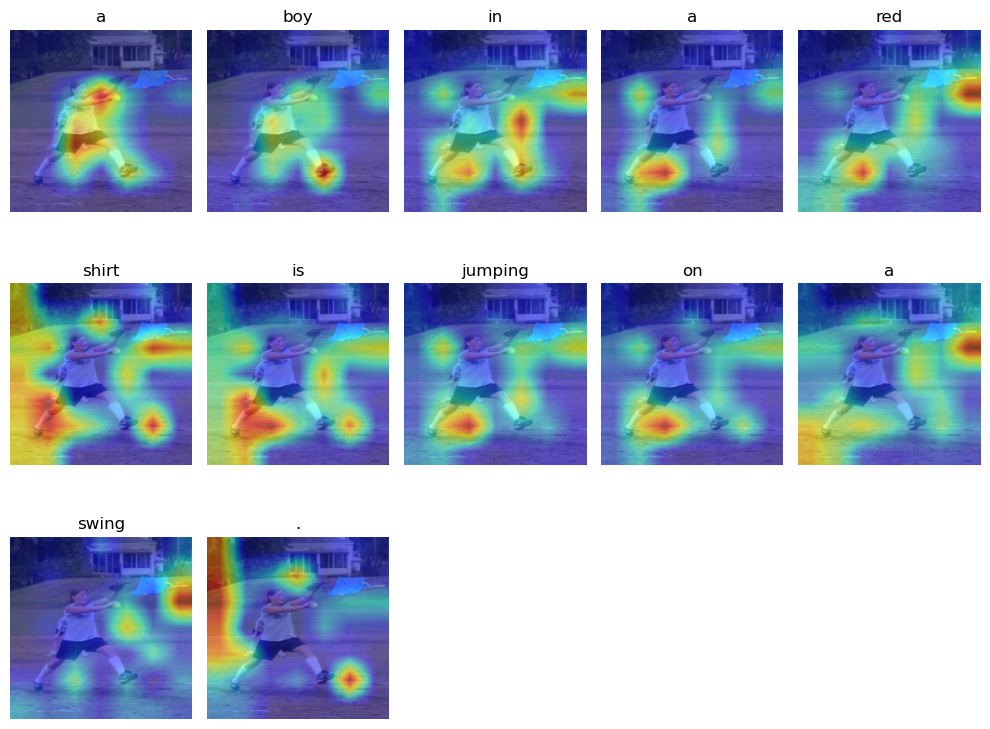

In [40]:
visualize_attention(333)

Predicted Captions: a boy in a red shirt is running on a swing .


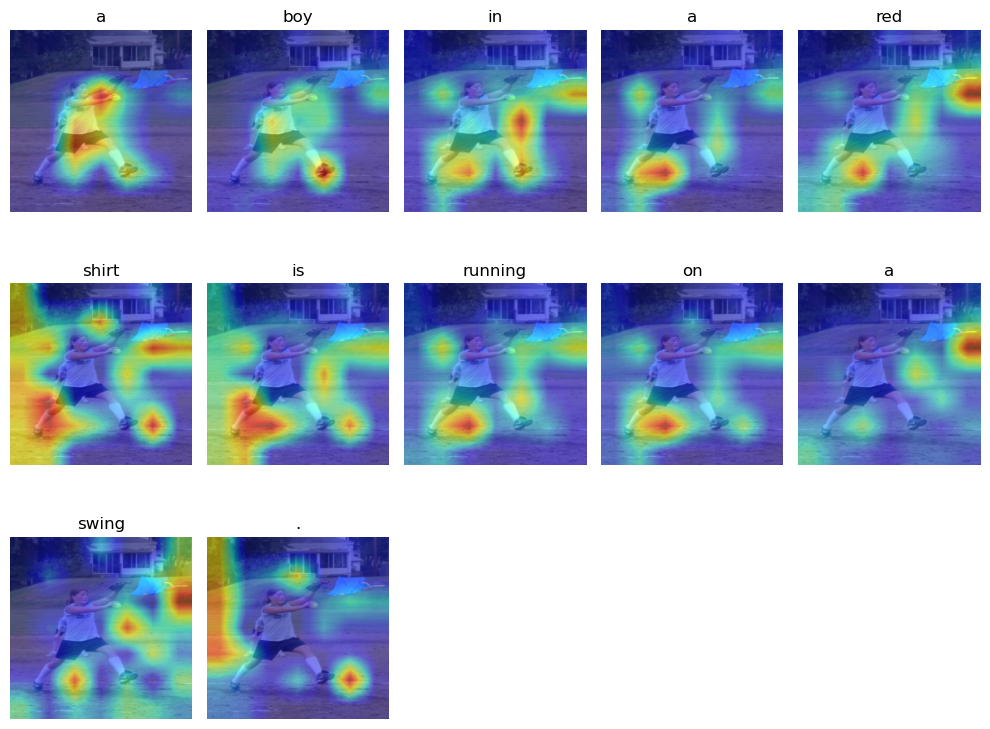

In [41]:
beam_visualize_attention(333)

In [42]:
def compare_decoding(indx):
    encoder.eval()
    decoder.eval()

    image, real_caption = test_dataset[indx]
    # Undo Image Normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    display_image = image.squeeze(0).cpu()
    display_image = display_image * std + mean
    display_image = display_image.clamp(0, 1) # Limiting tensor between 0 - 1
    display_image = display_image.permute(1, 2, 0).numpy()
    image = image.unsqueeze(0).to(device)

    real_caption = vocab.decode(real_caption.tolist())
    real_caption = real_caption.split()
    special_tokens = {"<start>", "<end>", "<pad>"}
    real_caption = [word for word in real_caption if word not in special_tokens]
    with torch.no_grad():
        features = encoder(image)

        greedy_caption, _ = decoder.generate_caption(
            features,
            vocab
        ) 

        beam_caption, _ = decoder.generate_caption_beam_search(
            features,
            vocab,
            beam_size = 3
        )

        print("Greedy Search:")
        print(" ".join(greedy_caption))
    
        print()
    
        print("Beam Search:")
        print(" ".join(beam_caption))
        print()
        print("Real Caption:")
        print(" ".join(real_caption))
        plt.imshow(display_image)
        plt.axis("off")

        # Verifying
        image_name = unique_images[indx]
        print(image_name)
        print(data_text[data_text["image"] == image_name]["caption"].tolist())

Greedy Search:
a dog runs through the grass .

Beam Search:
a dog runs through the grass .

Real Caption:
a dog prepares to catch a thrown object in a field with nearby cars .
103195344_5d2dc613a3.jpg
['A man in black is sitting next to a modern art structure in front of a glass building .', 'A man sits and reads a newspaper by a sculpture outside of an office building .', 'a man sits near a large statue .', 'A man sitting in front of a metal sculpture in front of a building .', 'The man with the backpack is sitting in a buildings courtyard in front of an art sculpture reading .']


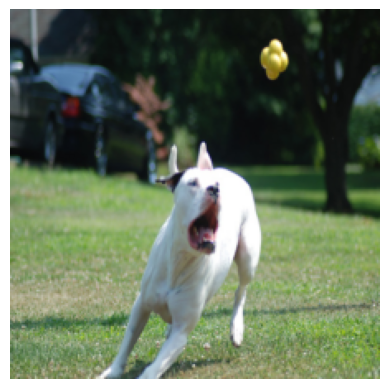

In [43]:
compare_decoding(5)

In [44]:
def predict_uploaded_image_all_words_attention(
    image_path,
    beam_search = True,
    beam_size = 3,
    show_attention = False
):
    """
    Genreate caption for uploaded image
    """
    encoder.eval()
    decoder.eval()
    # load image
    image = Image.open(image_path).convert("RGB")

    # Preprocessing
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_features = encoder(image_tensor)
        if beam_search:
            caption, attention = decoder.generate_caption_beam_search(
                encoder_features,
                vocab,
                beam_size = beam_size
            )
        else:
            caption, attention = decoder.generate_caption(
                encoder_features,
                vocab
            )
    # Display image
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    print("Caption : ", " ".join(caption))

    if not show_attention:
        return caption

    # Image overlay
    display_image = image_tensor.squeeze(0).cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    display_image = display_image * std + mean
    display_image = display_image.clamp(0, 1)
    display_image = display_image.permute(1, 2, 0).numpy()

    for i, word in enumerate(caption):

        if i >= len(attention):
            break
        alpha = attention[i]
        alpha = alpha.reshape(7, 7).unsqueeze(0).unsqueeze(0)

        alpha = F.interpolate(
            alpha,
            size = (224, 224),
            mode = "bilinear",
            align_corners = False
        )
        alpha = alpha.squeeze().cpu().numpy()

        plt.figure(figsize = (6, 6))
        plt.imshow(display_image)
        plt.imshow(alpha, alpha = 0.5, cmap = "jet")
        plt.title(word)
        plt.axis("off")
        plt.show()
    return caption

In [47]:
# a = predict_uploaded_image_all_words_attention("Test Image Manual/pp.jpg", beam_size = 5, show_attention = True)

In [48]:
def predict_uploaded_image(
    image_path,
    beam_search = True,
    beam_size = 3,
    show_attention = False
):
    """
    Generate caption for uploaded image
    """
    encoder.eval()
    decoder.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocessing
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_features = encoder(image_tensor)

        if beam_search:
            caption, attention = decoder.generate_caption_beam_search(
                encoder_features,
                vocab,
                beam_size = beam_size
            )
        else:
            caption, attention = decoder.generate_caption(
                encoder_features,
                vocab
            )

    # Display image
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Caption :", " ".join(caption))

    if not show_attention:
        return caption

    # Image overlay
    display_image = image_tensor.squeeze(0).cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    display_image = display_image * std + mean
    display_image = display_image.clamp(0, 1)
    display_image = display_image.permute(1, 2, 0).numpy()

    stop_words = {
    "a", "an", "the", "is", "are",
    "on", "in", "at", "of", "to",
    "with", "and", "by", "for",
    "from", "into", "over", "under"
    }
    
    plot_words = sum(word.lower() not in stop_words for word in caption)
    
    cols = 5
    rows = math.ceil(plot_words / cols)
    
    plt.figure(figsize=(10, 8))
    
    plot_idx = 1
    
    for word, alpha in zip(caption, attention):
    
        if word.lower() in stop_words or word == '.':
            continue
    
        alpha = alpha.reshape(7, 7).unsqueeze(0).unsqueeze(0)
    
        alpha = F.interpolate(
            alpha,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )
    
        alpha = alpha.squeeze().cpu().numpy()
    
        plt.subplot(rows, cols, plot_idx)
        plot_idx += 1
    
        plt.imshow(display_image)
        plt.imshow(alpha, cmap="jet", alpha=0.5)
    
        plt.title(word)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    return caption

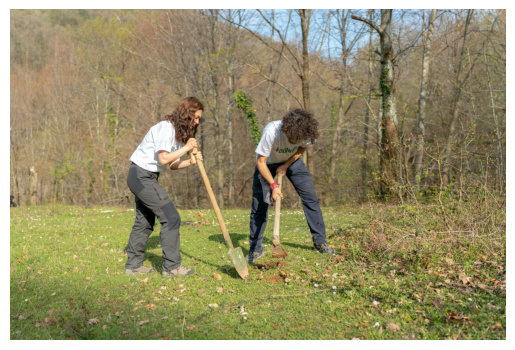

Caption : two people are walking on a grassy hill .


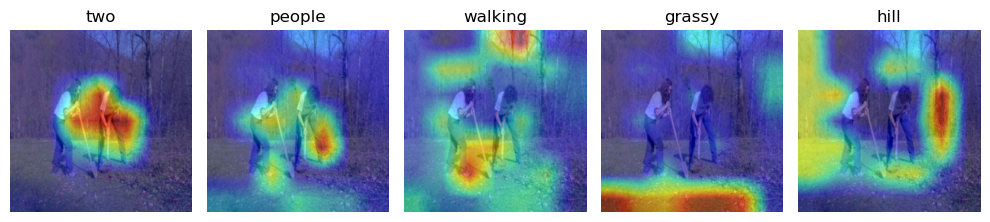

['two', 'people', 'are', 'walking', 'on', 'a', 'grassy', 'hill', '.']

In [49]:
predict_uploaded_image("Test Image Manual/pp.jpg", beam_size = 5, show_attention = True)

In [52]:
import inference

# print(vocab.__class__)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL __main__.Vocabulary was not an allowed global by default. Please use `torch.serialization.add_safe_globals([__main__.Vocabulary])` or the `torch.serialization.safe_globals([__main__.Vocabulary])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by d

In [ ]:
vocab.__class__.__module__ = "inference"

<class 'inference.Vocabulary'>
inference


In [57]:
print(vocab.__class__)
print(vocab.__class__.__module__)

<class 'inference.Vocabulary'>
inference


In [61]:
torch.save(
    {
        "word2idx": vocab.word2idx,
        "idx2word": vocab.idx2word,
        "min_freq": vocab.min_freq
    },
    "vocab.pth"
)